<a href="https://colab.research.google.com/github/Jayan04-MCC/google_vit_Proyect/blob/master/transformer_python/VisionTransformer_FashionMNIST_(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer con FashionMNIST



## Importando librerías

In [ ]:
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm_notebook

## Configurando algunos parámetros:

1.   **Semilla de random (42):** Genera números aleatorios específicos para pruebas (es modificable, pero si se desea probar el caso usar la semilla).
2.   **Configuración determinista de la GPU (torch.backends.cudnn.deterministic = True):** Fuerza a cuDNN (biblioteca de NVIDIA para redes neuronales) a usar algoritmos deterministas, así garantiza que las operaciones de convolución den resultados idénticos en cada ejecución.
3.   **Detección de GPU (device):** Detecta si hay GPU disponible, **Usa GPU** (CUDA) si existe (cuda:0 = primera tarjeta gráfica), en caso contrario **usa CPU.**

In [ ]:
# Configurando la semilla
random.seed(42)
g = torch.Generator().manual_seed(2147483647) # por reproducibilidad

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
# Asegurarse de que todas las operaciones son deterministicas en la GPU (si se usa) por reproducibilidad del programa.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda:0


# Hiperparametros

In [ ]:
image_size = 28
embed_dim=256
hidden_dim=embed_dim*3
num_heads=8
num_layers=6
patch_size=7
num_patches=16
num_channels=1
num_classes=10
dropout=0.2

## Descargando MNIST desde torchvision



In [ ]:
import torchvision
import torch
from torchvision import transforms

# Transformación igual a MNIST: ToTensor + Normalize a [-1, 1]
FASHION_preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descargar FashionMNIST para entrenamiento y separar validación
train_dataset = torchvision.datasets.FashionMNIST(
    root='/data/torchvision/FashionMNIST/training',
    train=True,
    download=True,
    transform=FASHION_preprocess
)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Conjunto de prueba
test_set = torchvision.datasets.FashionMNIST(
    root='/data/torchvision/FashionMNIST/testing',
    train=False,
    download=True,
    transform=FASHION_preprocess
)

# Cargadores de datos
train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_set, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=32, shuffle=False)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.44MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.0MB/s]


## Comprobación dimensional:
Debemos verificar que todos los datos (imágenes procesados) tengan las mismas dimensionalidades. En este caso lo hacemos de forma visual, revisando en consola si las dimensiones coinciden.

In [ ]:
# Imprimir la dimensión de las imágenes para verificar que todos los cargadores (loaders) tienen las mismas dimensiones.
def print_dim(loader, text):
  print('---------'+text+'---------')
  print(len(loader.dataset))
  for image, label in loader:
    print(image.shape)
    print(label.shape)
    break

print_dim(train_loader,'training loader')
print_dim(val_loader,'validation loader')
print_dim(test_loader,'test loader')

---------training loader---------
50000
torch.Size([32, 1, 28, 28])
torch.Size([32])
---------validation loader---------
10000
torch.Size([32, 1, 28, 28])
torch.Size([32])
---------test loader---------
10000
torch.Size([32, 1, 28, 28])
torch.Size([32])


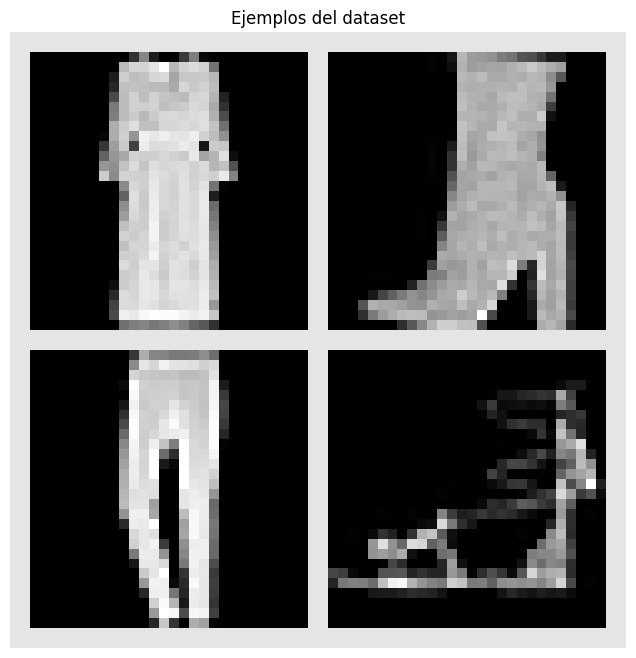

In [ ]:
# Ver algunos ejemplos
NUM_IMAGES = 4
MNIST_examples = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(MNIST_examples, nrow=2, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.title("Ejemplos del dataset")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

## Visualizando la función `img_to_patch`

In [ ]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Entradas:
        x - Tensor que representa la imagen con forma [B, C, H, W]
        patch_size - Número de píxeles por dimensión que tiene cada patch (entero)
        flatten_channels - Si es True, los patches se devolverán en formato aplanado
                           como un vector de características en lugar de una cuadrícula de imagen.
    """
    B, C, H, W = x.shape # [B, C, H, W], MNIST [B, 1, 28, 28]
    x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size) # [B, C, H', p_H, W', p_W], MNIST [B, 1, 4, 7, 4, 7]
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W], MNIST [B, 4, 4, 1, 7, 7]
    x = x.flatten(1, 2)  # [B, H'*W', C, p_H, p_W], MNIST [B, 16, 1, 7, 7]
    if flatten_channels:
        x = x.flatten(2, 4)  # [B, H'*W', C*p_H*p_W], MNIST [B, 16, 49]
    return x

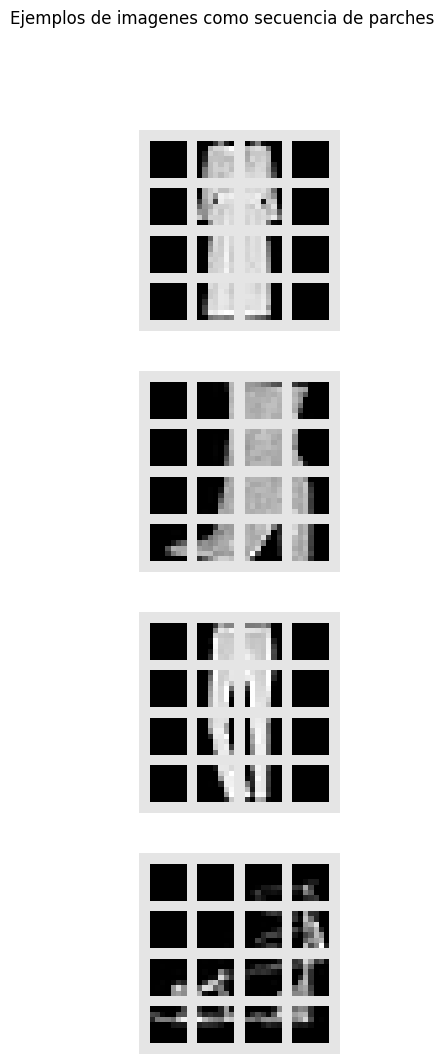

In [ ]:
# Visualize the image patches
img_patches = img_to_patch(MNIST_examples, patch_size=patch_size, flatten_channels=False)

fig, ax = plt.subplots(MNIST_examples.shape[0], 1, figsize=(14, 12))
fig.suptitle("Ejemplos de imagenes como secuencia de parches")
for i in range(MNIST_examples.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=int(image_size/patch_size), normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis("off")
plt.show()
plt.close()

## Clase VisionTransformer

In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Entradas:
            embed_dim - Dimensión de los vectores de características de entrada y de atención
            hidden_dim - Dimensión de la capa oculta en la red feed-forward
                         (usualmente 2 a 4 veces mayor que embed_dim)
            num_heads - Número de cabezas a usar en el bloque de Atención Multi-Cabeza
            dropout - Cantidad de dropout a aplicar en la red feed-forward
        """
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0]
        x = x + self.linear(self.layer_norm_2(x))
        return x

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
    ):
        """
        Entradas:
            embed_dim - Dimensión de los vectores de características de entrada al Transformer
            hidden_dim - Dimensión de la capa oculta en las redes feed-forward
                         dentro del Transformer
            num_channels - Número de canales de la imagen de entrada (3 para RGB o 1 para escala de grises)
            num_heads - Número de cabezas a usar en el bloque de Atención Multi-Cabeza
            num_layers - Número de capas a usar en el Transformer
            num_classes - Número de clases a predecir
            patch_size - Número de píxeles por dimensión que tiene cada patch
            num_patches - Número máximo de patches que puede tener una imagen
            dropout - Cantidad de dropout a aplicar en la red feed-forward y
                      en el codificado de entrada
        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)        # x.shape ---> batch, num_patches, (patch_size**2)
        B, T, _ = x.shape
        x = self.input_layer(x)                     # x.shape ---> batch, num_patches, embed_dim

        # Add CLS token and positional encoding (atención)
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)        # x.shape ---> batch, num_patches+1, embed_dim
        x = x + self.pos_embedding[:, : T + 1]      # x.shape ---> batch, num_patches+1, embed_dim

        # Apply Transformer
        x = self.dropout(x)
        x = x.transpose(0, 1)                       # x.shape ---> num_patches+1, batch, embed_dim
        x = self.transformer(x)                     # x.shape ---> num_patches+1, batch, embed_dim

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

## Inicializando el modelo

In [ ]:
model = VisionTransformer(embed_dim=embed_dim,
                          hidden_dim=hidden_dim,
                          num_heads=num_heads,
                          num_layers=num_layers,
                          patch_size=patch_size,
                          num_channels=num_channels,
                          num_patches=num_patches,
                          num_classes=num_classes,
                          dropout=dropout)

# Transfer to GPU
model.to(device)
model_restore = None #'/content/model_20230712_211204_0'
if model_restore is not None and os.path.exists(model_restore):
  model.load_state_dict(torch.load(model_restore))
  model.restored = True

In [ ]:
model

VisionTransformer(
  (input_layer): Linear(in_features=49, out_features=256, bias=True)
  (transformer): Sequential(
    (0): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (linear): Sequential(
        (0): Linear(in_features=256, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=768, out_features=256, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
    )
    (1): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): Layer

## Entrenamiento

In [ ]:
# setup the loss function
loss_fn = torch.nn.CrossEntropyLoss()
# setup the optimizer with the learning rate
model_optimizer = optim.Adam(model.parameters(), lr=3e-4)
# set a scheduler to decay the learning rate by 0.1 on the 100th 150th epochs
model_scheduler = optim.lr_scheduler.MultiStepLR(model_optimizer,
                                            milestones=[100, 150], gamma=0.1)

In [ ]:
# listas para las curvas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_vloss = 1_000_000

for epoch in range(20):
    model.train(True)
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm_notebook(train_loader, desc='epoch '+str(epoch)):
        imgs, labels = imgs.to(device), labels.to(device)
        model_optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, labels)
        loss.backward()
        model_optimizer.step()

        running_loss += loss.item()

        # Accuracy cálculo entrenamiento
        _, predicted = torch.max(preds, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Scheduler step
    model_scheduler.step()
    model.eval()

    running_vloss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs, vlabels = vinputs.to(device), vlabels.to(device)
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss.item()

            # Accuracy cálculo validación
            _, predicted = torch.max(voutputs, 1)
            correct_val += (predicted == vlabels).sum().item()
            total_val += vlabels.size(0)

    avg_vloss = running_vloss / len(val_loader)
    val_acc = correct_val / total_val
    val_losses.append(avg_vloss)
    val_accuracies.append(val_acc)

    print('Epoch {} => Train Loss {:.4f} | Val Loss {:.4f} | Train Acc {:.2f}% | Val Acc {:.2f}%'.format(
        epoch+1, avg_train_loss, avg_vloss, 100 * train_acc, 100 * val_acc))

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = '/model_VisionTransformer_MNIST_{}.pt'.format(epoch+1)
        torch.save(model.state_dict(), model_path)


epoch 0:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1 => Train Loss 0.5694 | Val Loss 0.4486 | Train Acc 79.17% | Val Acc 82.80%


epoch 1:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2 => Train Loss 0.4148 | Val Loss 0.4214 | Train Acc 84.75% | Val Acc 84.32%


epoch 2:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Epoch 18 => Train Loss 0.2714 | Val Loss 0.3221 | Train Acc 89.77% | Val Acc 88.21%


epoch 18:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 19 => Train Loss 0.2680 | Val Loss 0.3136 | Train Acc 89.92% | Val Acc 88.20%


epoch 19:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 20 => Train Loss 0.2635 | Val Loss 0.3151 | Train Acc 90.11% | Val Acc 88.25%


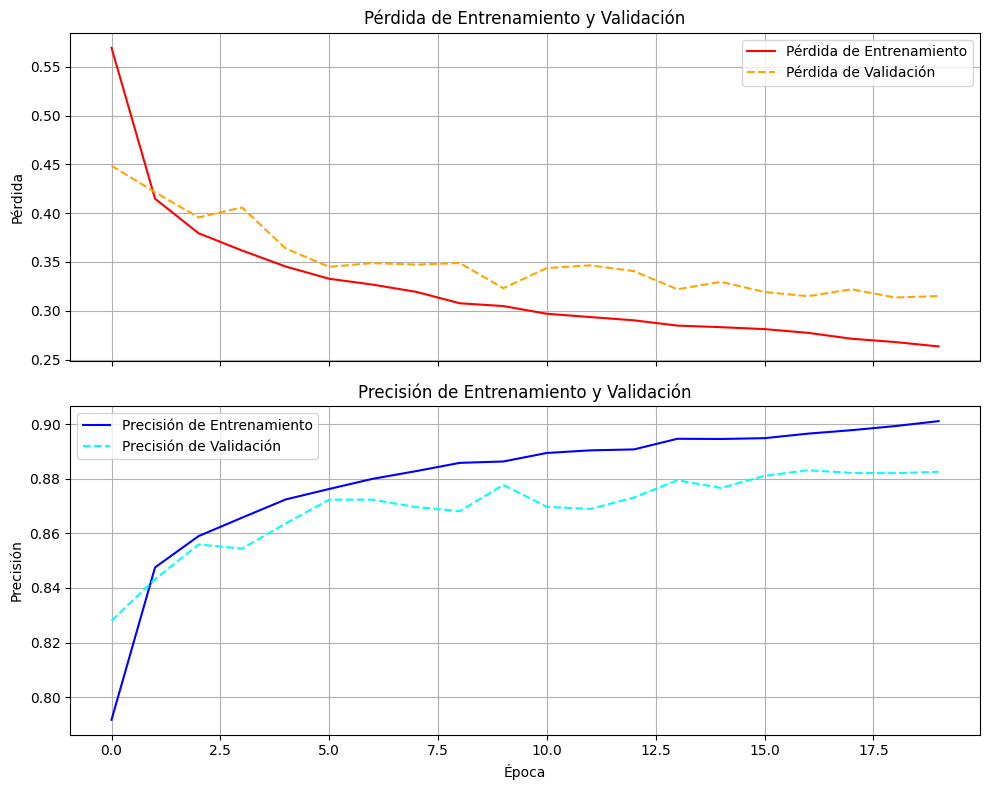

In [ ]:
# Convertir listas a tensores (por si usas operaciones de PyTorch)
tl = torch.tensor(train_losses)
vl = torch.tensor(val_losses)
ta = torch.tensor(train_accuracies)
va = torch.tensor(val_accuracies)

# Crear figura con 2 subgráficos (pérdida y precisión)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# === Subgráfico 1: Pérdida ===
ax1.plot(tl, label="Pérdida de Entrenamiento", color='red')
ax1.plot(vl, label="Pérdida de Validación", color='orange', linestyle='--')
ax1.set_ylabel("Pérdida")
ax1.set_title("Pérdida de Entrenamiento y Validación")
ax1.legend()
ax1.grid(True)

# === Subgráfico 2: Precisión ===
ax2.plot(ta, label="Precisión de Entrenamiento", color='blue')
ax2.plot(va, label="Precisión de Validación", color='cyan', linestyle='--')
ax2.set_xlabel("Época")
ax2.set_ylabel("Precisión")
ax2.set_title("Precisión de Entrenamiento y Validación")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# Pruebas sobre Test

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Poner el modelo en modo evaluación
model.eval()

# Acumuladores
todas_las_predicciones = []
todas_las_etiquetas = []

with torch.no_grad():
    for imgs, etiquetas in tqdm_notebook(test_loader):
        imgs, etiquetas = imgs.to(device), etiquetas.to(device)
        salidas = model(imgs)
        predicciones = salidas.argmax(dim=1)

        todas_las_predicciones.extend(predicciones.cpu().numpy())
        todas_las_etiquetas.extend(etiquetas.cpu().numpy())

# Calcular métricas
exactitud = accuracy_score(todas_las_etiquetas, todas_las_predicciones)
exactitud_balanceada = balanced_accuracy_score(todas_las_etiquetas, todas_las_predicciones)
precision = precision_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
sensibilidad = recall_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
f1 = f1_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
matriz_confusion = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)

# Reporte
print("\n📊 Métricas de Evaluación en el Conjunto de Prueba:")
print(f"Exactitud:              {exactitud:.4f}")
print(f"Exactitud Balanceada:   {exactitud_balanceada:.4f}")
print(f"Precisión (macro):      {precision:.4f}")
print(f"Sensibilidad (Recall):  {sensibilidad:.4f}")
print(f"Puntaje F1 (macro):     {f1:.4f}")

# Mostrar la matriz de confusión
print("\nMatriz de Confusión:")
print(matriz_confusion)

# Reporte detallado por clase
print("\nReporte de Clasificación Detallado:")
print(classification_report(todas_las_etiquetas, todas_las_predicciones, digits=4))


  0%|          | 0/313 [00:00<?, ?it/s]


📊 Métricas de Evaluación en el Conjunto de Prueba:
Exactitud:              0.8840
Exactitud Balanceada:   0.8840
Precisión (macro):      0.8847
Sensibilidad (Recall):  0.8840
Puntaje F1 (macro):     0.8838

Matriz de Confusión:
[[822   2  12  52   6   1  97   0   8   0]
 [  0 960   1  32   2   0   4   0   1   0]
 [ 16   0 784  19  92   0  87   0   2   0]
 [ 13   3   6 936  21   0  17   0   4   0]
 [  0   1  50  34 835   0  80   0   0   0]
 [  0   0   0   2   0 963   0  20   2  13]
 [121   1  71  48  69   1 685   0   4   0]
 [  0   0   0   0   0  30   0 932   0  38]
 [  2   0   1   9   2   8  10   2 965   1]
 [  0   0   0   1   0  14   1  26   0 958]]

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0     0.8439    0.8220    0.8328      1000
           1     0.9928    0.9600    0.9761      1000
           2     0.8476    0.7840    0.8145      1000
           3     0.8261    0.9360    0.8776      1000
           4     0.8130    0.835


## Pruebas de atención:
Con una muestra de prueba y la corremos a través del primer bloque de atención.

In [ ]:
test_sample_index = (test_set.targets==7).nonzero(as_tuple=True)[0][5].item()

In [ ]:
# Extraer una muestra del conjunto de prueba
img_tensor = test_set.data[test_sample_index].to(device)

# Convertir la muestra de prueba en parches (patches)
patches = img_to_patch(img_tensor.unsqueeze(0).unsqueeze(0), patch_size=patch_size)

# Pasar los parches por la capa de entrada para obtener un tensor de tamaño embed_dim
patches = model.input_layer(patches.float())

# Adjuntar el token de clase y sumar el embedding posicional
transformer_input = torch.cat((model.cls_token, patches), dim=1) + model.pos_embedding
print("Input tensor to Transformer: ", transformer_input.shape)

# Pasar la imagen embebida por el primer bloque de atención y eliminar la dimensión del batch
# porque estamos usando solo una imagen de prueba
transformer_input_expanded = model.transformer[0].linear[0](transformer_input).squeeze(0)
print("transformer_input_expanded shape: ", transformer_input_expanded.shape)


Input tensor to Transformer:  torch.Size([1, 17, 256])
transformer_input_expanded shape:  torch.Size([17, 768])


In [ ]:
# Redimensionar la salida del primer bloque de atención al tamaño (num_patches+1, 3, num_heads, -1)
qkv = transformer_input_expanded.reshape(num_patches+1, 3, num_heads, -1)
print("qkv shape: ", qkv.shape)

# Extraer la matriz de queries (consultas) y reorganizar las dimensiones a (8 cabezas, 17 patches, 32 canales)
# Hacer lo mismo para la matriz de keys (claves)
q = qkv[:, 0].permute(1, 0, 2)
k = qkv[:, 1].permute(1, 0, 2)
print("q shape: ", q.shape)
print("k shape: ", k.shape)

# Transponer la matriz k para que tenga forma adecuada para el producto con q
kT = k.permute(0, 2, 1)

# El resultado de multiplicar q @ kT es una matriz cuadrada de 17x17 que muestra
# cómo cada patch "presta atención" a cada otro patch
attention_matrix = q @ kT
print("attention matrix: ", attention_matrix.shape)

qkv shape:  torch.Size([17, 3, 8, 32])
q shape:  torch.Size([8, 17, 32])
k shape:  torch.Size([8, 17, 32])
attention matrix:  torch.Size([8, 17, 17])


In [ ]:
# Promediar los pesos de atención entre todas las cabezas tomando la media a lo largo
# de la primera dimensión (dim=0)
attention_matrix_mean = torch.mean(attention_matrix, dim=0)
print("attention matrix mean: ", attention_matrix_mean.shape)

# Para tener en cuenta las conexiones residuales, se suma una matriz identidad
# a la matriz de atención y se re-normalizan los pesos.
# Ver el paper de attention rollout: https://arxiv.org/abs/2005.00928
residual_att = torch.eye(attention_matrix_mean.size(1)).to(device)
aug_att_mat = attention_matrix_mean + residual_att
print("augmented attention matrix: ", aug_att_mat.shape)

# Normalizar la matriz de atención aumentada para que cada fila sume 1
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)
print("normalized augmented attention matrix: ", aug_att_mat.shape)

attention matrix mean:  torch.Size([17, 17])
augmented attention matrix:  torch.Size([17, 17])
normalized augmented attention matrix:  torch.Size([17, 17])


## Trazando (plotting) attention
Ahora tenemos una matriz cuadrada normalizada de tamaño $17\times 17$. Cuando se traza la primera columna corresponde a la etiqueta de clase (class token).
Las $16$ columnas restantes serán redistribuidas en matrices de $4\times 4$  (patch), ordenadas de tal forma que cada parche (patch) tiene su posición en la imagen.

 Para mejor visualización, usamos la función `interpolate` de forma que redistribuimos las matrices $4\times 4$ en la forma $28\times 28$ (por conveniencia de visualización).

attn_heatmap:  torch.Size([4, 4])
attn_heatmap_resized:  torch.Size([28, 28, 1])


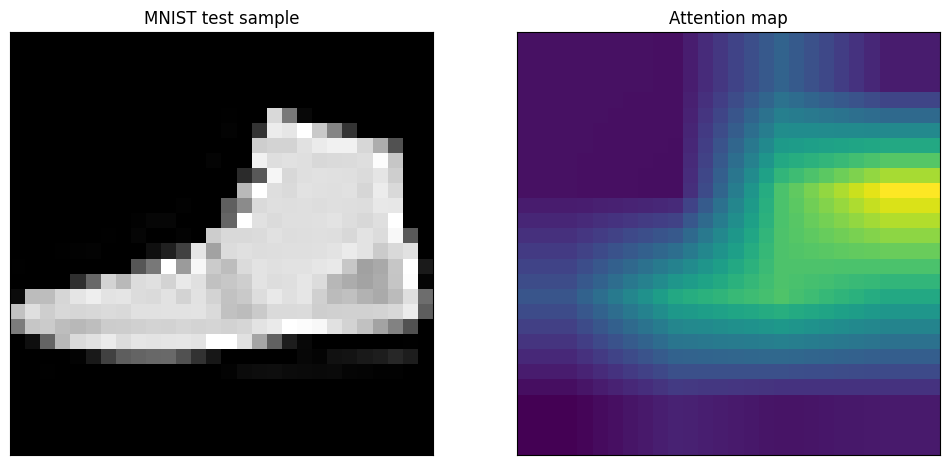

In [ ]:
attn_heatmap = aug_att_mat[0, 1:].reshape((int(image_size/patch_size), int(image_size/patch_size)))
print("attn_heatmap: ", attn_heatmap.shape)
attn_heatmap_resized = F.interpolate(attn_heatmap.unsqueeze(0).unsqueeze(0), [image_size, image_size], mode='bilinear').view(28, 28, 1)
print("attn_heatmap_resized: ", attn_heatmap_resized.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
img = np.asarray(img_tensor.cpu())
ax1.imshow(img, cmap='gray')
ax1.set_title('MNIST test sample')
ax1.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
               labelbottom=False, labeltop=False, labelleft=False, labelright=False)

ax2.imshow(attn_heatmap_resized.detach().cpu().numpy())
ax2.set_title('Attention map')
ax2.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labeltop=False, labelleft=False, labelright=False)

# Guardar modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch

# Crear carpeta si no existe
ruta_modelo = "/content/drive/MyDrive/modelos"
os.makedirs(ruta_modelo, exist_ok=True)

# Guardar pesos del modelo
nombre_archivo = "modelo_transformer_Fashionmnist.pth"
ruta_completa = os.path.join(ruta_modelo, nombre_archivo)
torch.save(model.state_dict(), ruta_completa)

print(f"✅ Modelo guardado en Google Drive: {ruta_completa}")

✅ Modelo guardado en Google Drive: /content/drive/MyDrive/modelos/modelo_transformer_Fashionmnist.pth
